In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [15]:
pokedex = pd.read_csv('data/viz_pokemon.csv')
pokedex.head()

,ID,Name,Type 1,Type 2,Abilities,HiddenAbility,Generation,Hp,Attack,Defense,...,DamageFromSteel,DamageFromFire,DamageFromWater,DamageFromGrass,DamageFromElectric,DamageFromPsychic,DamageFromIce,DamageFromDragon,DamageFromDark,DamageFromFairy
0,1,Bulbasaur,Grass,Poison,['Overgrow'],['Chlorophyll'],I,45.0,49.0,49.0,...,1.0,2.0,0.5,0.25,0.5,2.0,2.0,1.0,1.0,0.5
1,2,Ivysaur,Grass,Poison,['Overgrow'],['Chlorophyll'],I,60.0,62.0,63.0,...,1.0,2.0,0.5,0.25,0.5,2.0,2.0,1.0,1.0,0.5
2,3,Venusaur,Grass,Poison,['Overgrow'],['Chlorophyll'],I,80.0,82.0,83.0,...,1.0,2.0,0.5,0.25,0.5,2.0,2.0,1.0,1.0,0.5
3,4,Mega Venusaur,Grass,Poison,Thick Fat,[],I,80.0,100.0,123.0,...,1.0,1.0,0.5,0.25,0.5,2.0,1.0,1.0,1.0,0.5
4,5,Charmander,Fire,NaN,['Blaze'],['Solar Power'],I,39.0,52.0,43.0,...,0.5,0.5,2.0,0.50,1.0,1.0,0.5,1.0,1.0,0.5


In [16]:
combats = pd.read_csv('data/combats.csv')
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [17]:
pokedex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 48 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    int64  
 1   Name                800 non-null    object 
 2   Type 1              800 non-null    object 
 3   Type 2              414 non-null    object 
 4   Abilities           800 non-null    object 
 5   HiddenAbility       800 non-null    object 
 6   Generation          800 non-null    object 
 7   Hp                  800 non-null    float64
 8   Attack              800 non-null    float64
 9   Defense             800 non-null    float64
 10  SpecialAttack       800 non-null    float64
 11  SpecialDefense      800 non-null    float64
 12  Speed               800 non-null    float64
 13  TotalStats          800 non-null    float64
 14  Weight              800 non-null    float64
 15  Height              800 non-null    float64
 16  GenderPr

In [18]:
# columns with missing values
pokedex.columns[pokedex.isnull().any()]

Index(['Type 2'], dtype='object')

In [19]:
pokedex['Type 2'] = pokedex['Type 2'].fillna('None', inplace=True)

C:\Users\tuann\AppData\Local\Temp\ipykernel_15012\2425436126.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pokedex['Type 2'] = pokedex['Type 2'].fillna('None', inplace=True)


In [20]:
pokedex.duplicated().sum()

np.int64(0)

## Biến đổi Winner thành binary


In [21]:
combats['Winner'] = np.where(combats['Winner'] == combats['First_pokemon'], 0, 1)
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,1
1,702,701,1
2,191,668,1
3,237,683,1
4,151,231,0


Quy ước được dùng là:

0: Nếu Pokemon ở vị trí First_pokemon thắng.

1: Nếu Pokemon ở vị trí Second_pokemon thắng.

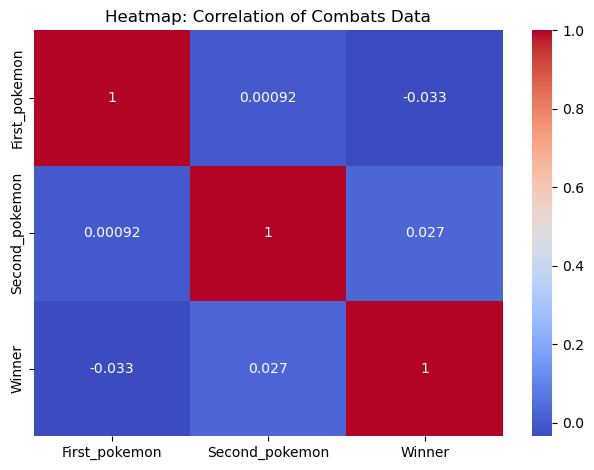

In [22]:
figsize=(9, 6)

combats_corr = combats.corr()
sns.heatmap(combats_corr, annot=True, cmap='coolwarm')
plt.title('Heatmap: Correlation of Combats Data')

plt.tight_layout()
plt.show()

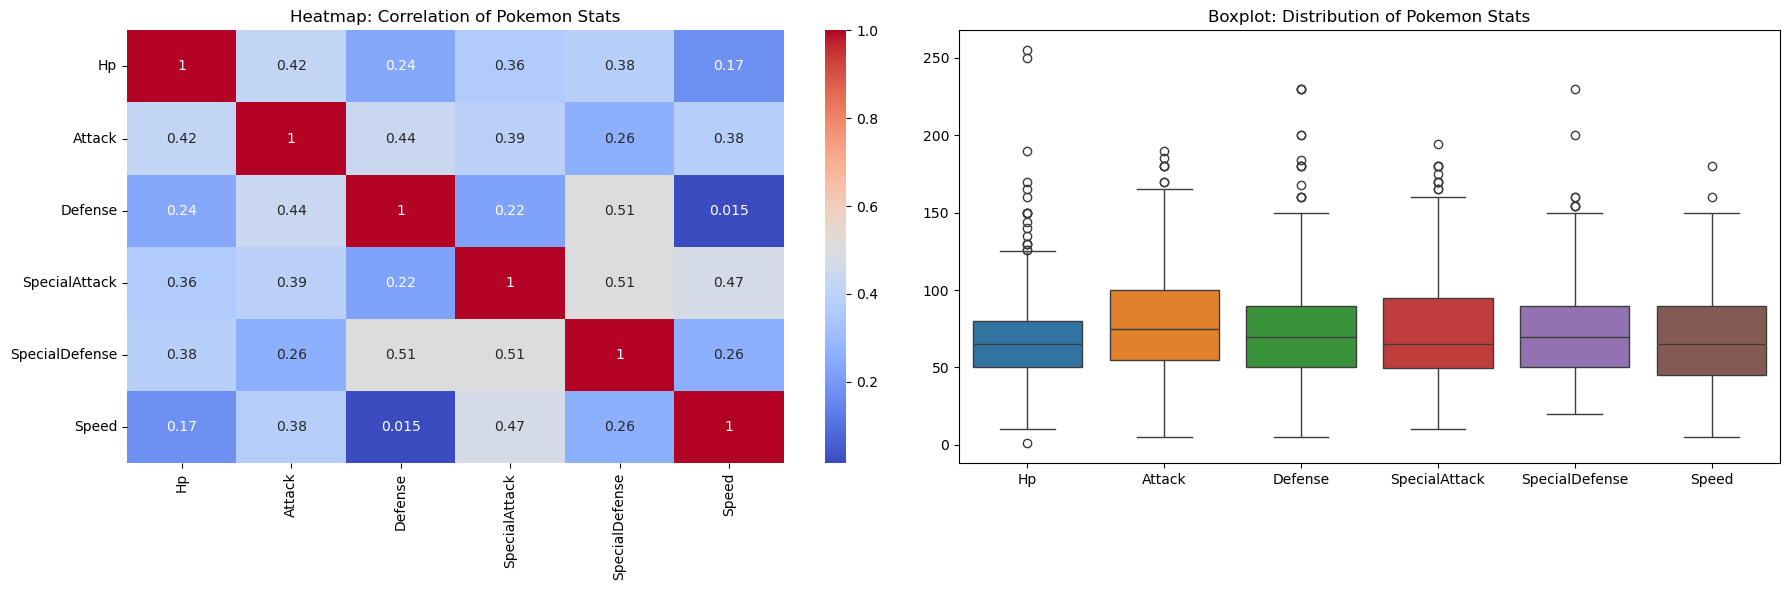

In [23]:

stats_cols = ['Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed']
pokemon_stats = pokedex[stats_cols]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pokemon_corr = pokemon_stats.corr()
sns.heatmap(pokemon_corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Heatmap: Correlation of Pokemon Stats')

sns.boxplot(data=pokemon_stats, ax=axes[1])
axes[1].set_title('Boxplot: Distribution of Pokemon Stats')

plt.tight_layout()
plt.show()

## Feature Selection

C:\Users\tuann\AppData\Local\Temp\ipykernel_15012\200454361.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


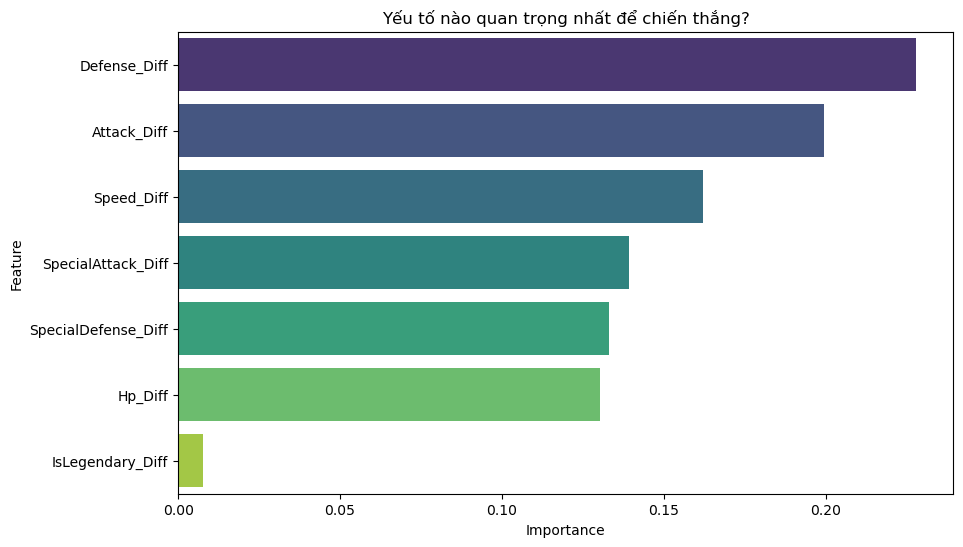

               Feature  Importance
2         Defense_Diff    0.227967
1          Attack_Diff    0.199446
5           Speed_Diff    0.162220
3   SpecialAttack_Diff    0.139354
4  SpecialDefense_Diff    0.133036
0              Hp_Diff    0.130261
6     IsLegendary_Diff    0.007716


In [26]:
stats_cols = ['ID', 'Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'IsLegendary']
pokemon_stats = pokedex[stats_cols]

# 3. Merge (Ghép) chỉ số vào bảng Combats
# Ghép cho Pokemon 1
p1_stats = pokemon_stats.add_suffix('_1').rename(columns={'ID_1': 'First_pokemon'})
combats_full = combats.merge(p1_stats, on='First_pokemon', how='left')

# Ghép cho Pokemon 2
p2_stats = pokemon_stats.add_suffix('_2').rename(columns={'ID_2': 'Second_pokemon'})
combats_full = combats_full.merge(p2_stats, on='Second_pokemon', how='left')

# 4. Feature Engineering: Tính chênh lệch (P1 - P2)
cols_to_diff = ['Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'IsLegendary']
diff_cols = []
for col in cols_to_diff:
    diff_name = f'{col}_Diff'
    combats_full[diff_name] = combats_full[f'{col}_1'] - combats_full[f'{col}_2']
    diff_cols.append(diff_name)

# 5. Tạo cột Target (0: P1 thắng, 1: P2 thắng)
# Lưu ý: Cột Winner gốc chứa ID, ta cần chuyển nó thành 0/1
combats_full['Target'] = combats_full.apply(lambda x: 0 if x['Winner'] == x['First_pokemon'] else 1, axis=1)

# 6. Chạy Feature Selection (Random Forest)
X = combats_full[diff_cols]
y = combats_full['Target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 7. Hiển thị kết quả
feature_importance = pd.DataFrame({
    'Feature': diff_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Yếu tố nào quan trọng nhất để chiến thắng?')
plt.show()

print(feature_importance)

Kết quả Feature Importance cho thấy một cấu trúc dự đoán chiến thắng dựa trên khả năng bền vững (sustainability) và sức tấn công vật lý (physical offense), trong đó không có một chỉ số nào chiếm ưu thế tuyệt đối.

- Chỉ số phòng ngự:

Khả năng **chống chịu** là chỉ số tiên đoán quan trọng nhất trong tập dữ liệu chiến đấu này. Cụ thể, yếu tố **Defense\_Diff** (chênh lệch Phòng thủ Vật lý) là đặc trưng dự đoán mạnh nhất, khẳng định rằng khả năng **sống sót qua sát thương vật lý** là yếu tố quyết định hàng đầu. Khi tổng hợp các chỉ số thuộc nhóm phòng thủ bao gồm `Defense_Diff` (22.80%), `SpecialDefense_Diff` (13.30%) và `Hp_Diff` (13.03%), nhóm này chiếm tổng cộng **50.13%** mức độ quan trọng. Tỷ lệ này xác lập chiến lược **"Đỡ đòn và Bền vững"** là mô hình chiến thắng hiệu quả nhất mà thuật toán đã học được.

- Chỉ số tấn công:

Các chỉ số tấn công duy trì tầm quan trọng đáng kể, đóng vai trò hỗ trợ cần thiết cho chiến lược phòng thủ. Cụ thể, Attack_Diff (19.94%) là yếu tố dự đoán mạnh thứ hai, trong khi SpecialAttack_Diff (13.94%) đứng thứ tư. Sự kết hợp giữa mức độ quan trọng cao của Defense_Diff và Attack_Diff cho thấy chiến thắng thường thuộc về nhóm Pokemon có chỉ số Phòng thủ cao cùng khả năng Tấn công vật lý mạnh mẽ (Bruiser archetype). Nhóm này tận dụng khả năng sống sót sau đòn tấn công ban đầu của đối thủ để thực hiện đòn phản công dứt điểm, làm nổi bật vai trò không thể thiếu của sức tấn công trong việc chuyển hóa lợi thế phòng thủ thành chiến thắng.

- Chỉ số tốc độ:

Chỉ số **Speed\_Diff** (chênh lệch Tốc độ) chỉ xếp hạng 3 với mức độ quan trọng là 16.22%. Mặc dù vẫn là một đặc trưng quan trọng trong mô hình, vai trò dự đoán của nó đã **giảm đi đáng kể** khi so sánh với các chỉ số bền vững (Defense/HP) và tấn công (Attack). Sự suy giảm này ngụ ý rằng lợi thế truyền thống của việc **được đánh trước** có thể bị vô hiệu hóa hoặc không còn là yếu tố quyết định nếu đối thủ có sự chênh lệch lớn hơn về khả năng **chống chịu** hoặc **sát thương**. Nói cách khác, tốc độ không còn đảm bảo chiến thắng nếu Pokemon không thể hạ gục đối thủ hoặc không thể sống sót qua đòn phản công sau đó.

- Tính Thừa Thãi Của Đặc Trưng Định Danh

Đặc trưng phân loại IsLegendary_Diff có độ quan trọng rất thấp (0.77%).

**Kết luận:** Mô hình không dựa vào nhãn phân loại "Huyền thoại" để đưa ra dự đoán. Giá trị dự đoán của một Pokemon đã được phản ánh đầy đủ thông qua các chỉ số chiến đấu cơ bản (Hp, Attack, Defense, v.v.), khiến nhãn này trở thành đặc trưng thừa thãi (redundant feature).

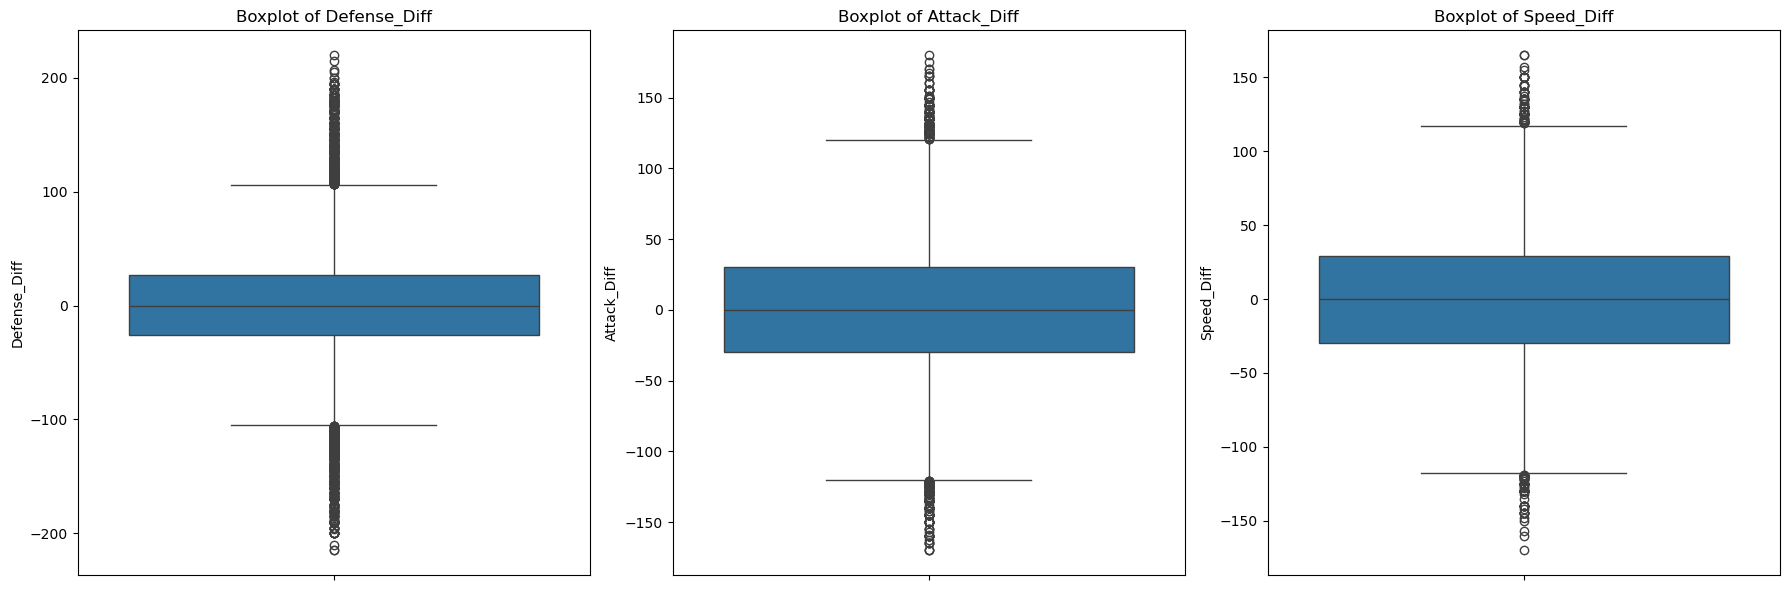

In [27]:
top_diff_cols = ['Defense_Diff', 'Attack_Diff', 'Speed_Diff']
stat_names = ['Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'IsLegendary']

for col in stat_names:
    combats_full[f'{col}_Diff'] = combats_full[f'{col}_1'] - combats_full[f'{col}_2']

# 4. Outlier Analysis (using Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(top_diff_cols):
    sns.boxplot(y=combats_full[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Các giá trị cực đoan này có khả năng gây ảnh hưởng đến biến mục tiêu và dẫn đến Overfitting nếu không được xử lý, đặc biệt là với các mô hình tuyến tính (như Hồi quy Logistic).

Defense_Diff (Nguy cơ cao nhất): Với 1319 trận đấu có chênh lệch phòng thủ cực lớn, mô hình có thể bị "dạy" rằng nếu Defense_Diff > 100, thì Pokemon 1 chắc chắn thắng, bất kể các yếu tố khác. Điều này làm cho mô hình hoạt động kém khi gặp phải các tình huống thực tế phức tạp hơn.

Ảnh hưởng đến Biến Mục tiêu: Nếu một chỉ số chênh lệch cực lớn (ví dụ: Defense_Diff = 200) luôn dẫn đến một kết quả (Winner = 0), mô hình sẽ học thuộc lòng mối quan hệ này thay vì học được xu hướng chung, dẫn đến hiệu suất thấp trên dữ liệu mới (unseen data).

**GPT** said:

Để giảm thiểu rủi ro overfitting do outliers, bạn nên áp dụng các kỹ thuật sau trước khi huấn luyện mô hình cuối cùng:Duy trì Mô hình Cây Quyết Định (Decision Tree-based Models):Các mô hình dựa trên cây (như Random Forest mà bạn đã dùng) thường ít bị ảnh hưởng bởi outliers hơn so với mô hình tuyến tính, vì chúng dựa vào việc chia dữ liệu thành các ngưỡng (threshold) thay vì khoảng cách. Do đó, bạn có thể tiếp tục sử dụng Random Forest.

Xử lý Outliers (Nếu chuyển sang mô hình Tuyến tính hoặc Mạng Nơ-ron):Capping (Giới hạn): Giới hạn các giá trị cực đoan ở ngưỡng trên và dưới của IQR (ví dụ: giới hạn Defense_Diff trong khoảng $[-105.5, 106.5]$).Loại bỏ (Removal): Loại bỏ các hàng có chứa outliers, nhưng điều này thường không được khuyến khích vì làm mất thông tin (ví dụ: loại bỏ 1319 hàng cho Defense_Diff).Biến đổi Log (Log Transformation): Có thể áp dụng để giảm độ lệch của phân phối.